**Exercise 5.1**

i) Generate an array of random integer numbers in range [10,1000] with size 100;
 
ii) Discritise this array into k= 10 bins, such that each bin is of equal width using (delta = xmax - xmin/k);

iii) Plot the histogram;

iv) Reapet i)-iii) by generating an array of random numbers by normal distribution with (loc=0.0, scale=1.0, size = 100);

v) Generate an array of random numbers by lognormal distribution with (mean=2.0, sigma=2.0, size=100) and setting bins as [0, 1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,90, 100].

In [1]:
import scipy.stats as stats
import seaborn as sns
sns.set()
import pandas as pd
import numpy as np # imported numpy module to generate random numbers
import matplotlib.pyplot as plt #imported matplotlib to plot the histogram
import math # imported math module to make the bins of histogram of equal width

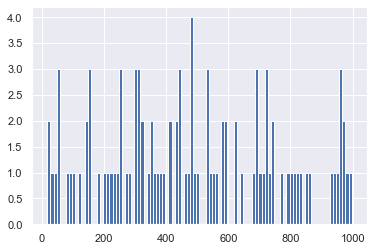

In [2]:
#Generate array of Random Integers from 10 to 1000 with size 100

df_arr = np.random.randint(low = 10, high = 1000, size = 100) # random.randint generates random integers

# Discritising array into 10 bins
k = 10
bins = math.ceil((df_arr.max() - df_arr.min()) / k) #Made the bins of equal width

#Plotting Histogram
hist_plot = plt.hist(df_arr, bins = bins) #Plotted the histogram

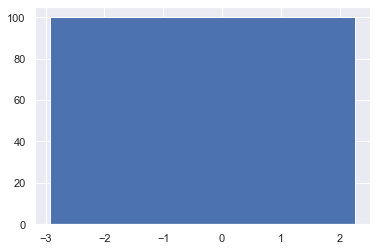

In [3]:
normal = np.random.normal(0.0, 1.0, 100) #Generated random numbers from normal distribution
k = 10
bins = math.ceil((normal.max() - normal.min()) / k) #Made the bins of equal width
hist_plot2 = plt.hist(normal, bins = bins) #Plotted the histogram of normal random numbers

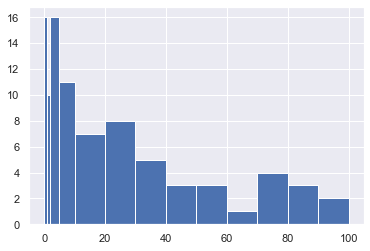

In [4]:
#generating array of random numbers by lognormal distribution with mean=2.0, sigma=2.0 and size=100
lognormal_arr = np.random.lognormal(mean=2.0, 
                          sigma=2.0, 
                          size=100) #  array of random numbers by lognormal distribution with (mean=2.0, sigma=2.0, size=100)

# setting bins as [0, 1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,90, 100].
bins=[0, 1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90,100]
plt.hist(lognormal_arr, bins=bins);

**Exercise 5.2**

Generate a data frame with 3 columns and 200 rows by selecting randomly selected numers: use for the first column the "normal" distribution with (loc=0.0, scale=1.0, size=200) and for the last 2 columns the "exponential" distribution with (mean=0.0, sigma=2.0, size=200) and (mean=1.0, sigma=3.0, size=200).

Find any outlier with a z-value > 3 or z-value <- 3 and replace that with the mean of the values, eg perform Mean substitution for outliers.

Write a report about cells with outliers, thier z-scores and substituted values. 


C:\Users\Georg\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Georg\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Georg\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-lev

<AxesSubplot:xlabel='Expdist2', ylabel='Density'>

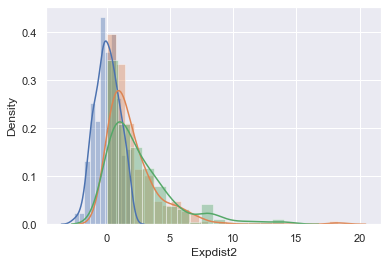

In [5]:
gen_df = pd.DataFrame(columns=["Normaldist", "Expdist1", "Expdist2"])

gen_df["Normaldist"]=np.random.normal(0, 1, 200)
gen_df["Expdist1"]=np.random.exponential(2, 200)
gen_df["Expdist2"]=np.random.exponential(3, 200)

sns.distplot(gen_df["Normaldist"])

sns.distplot(gen_df["Expdist1"])

sns.distplot(gen_df["Expdist2"])



In [6]:
# calculate summary statistics

mean = np.mean(gen_df)
std = np.std(gen_df)


meanExpdist1 = np.mean(gen_df['Expdist1'])
stdExpdist1 = np.std(gen_df['Expdist1'])

meanExpdist2 = np.mean(gen_df['Expdist2'])
stdExpdist2 = np.std(gen_df['Expdist2'])

meanNormaldist = np.mean(gen_df['Normaldist'])
stdNormaldist = np.std(gen_df['Normaldist'])

print(mean)
print(std)
print("--------------------------------------------")
print('mean of the dataset in coloumn Expdist1 is', meanExpdist1)
print('std. deviation is for colum Expdist1', stdExpdist1)
print("--------------------------------------------")
print('mean of the dataset in coloumn Expdist2 is', meanExpdist2)
print('std. deviation is for colum Expdist2', stdExpdist2)
print("--------------------------------------------")
print('mean of the dataset in coloumn Normaldist is', meanNormaldist)
print('std. deviation is for colum Normaldist', stdNormaldist)



Normaldist    0.051287
Expdist1      2.018016
Expdist2      2.618763
dtype: float64
Normaldist    0.939668
Expdist1      2.112585
Expdist2      2.655379
dtype: float64
--------------------------------------------
mean of the dataset in coloumn Expdist1 is 2.0180163040613808
std. deviation is for colum Expdist1 2.112584559144859
--------------------------------------------
mean of the dataset in coloumn Expdist2 is 2.6187631153235618
std. deviation is for colum Expdist2 2.655379371617513
--------------------------------------------
mean of the dataset in coloumn Normaldist is 0.0512873811896293
std. deviation is for colum Normaldist 0.9396679876203995


In [7]:
zscores = stats.zscore(gen_df, axis=0) #save zscore values at index of value gen_df
zscores.head(8)

#create array of outliers to which a value is input if the zscore is an outlier
outliers = zscores[(zscores > 3) | (zscores < -3)] 

print(outliers)
outliers.isna().sum()

     Normaldist  Expdist1  Expdist2
0           NaN       NaN       NaN
1           NaN       NaN       NaN
2           NaN       NaN       NaN
3           NaN       NaN       NaN
4           NaN       NaN       NaN
..          ...       ...       ...
195         NaN       NaN       NaN
196         NaN       NaN       NaN
197         NaN       NaN       NaN
198         NaN       NaN       NaN
199         NaN       NaN       NaN

[200 rows x 3 columns]


Normaldist    200
Expdist1      198
Expdist2      195
dtype: int64

In [8]:
outliers_Expdist1 = outliers['Expdist1'].dropna(how='all') # save only outliers to the array
#Extracting the expdist1 column from the raw data

print(outliers_Expdist1)

Expdist1_cleaned = gen_df['Expdist1']

#Dropping/assigning NaN to the outliers
for i in outliers_Expdist1.index:
    Expdist1_cleaned = Expdist1_cleaned.drop([i]) #drop values to 0 at the index of i in outliers_Expdist1

print(Expdist1_cleaned)



75    7.701152
99    3.360037
Name: Expdist1, dtype: float64
0      1.751141
1      3.147963
2      3.274980
3      0.558921
4      2.080475
         ...   
195    1.318438
196    0.745064
197    0.489085
198    2.066245
199    1.559367
Name: Expdist1, Length: 198, dtype: float64


In [9]:
#Extracting the Expdist2 outliers from the outliers table
outliers_Expdist2 = outliers['Expdist2'].dropna(how='all')
outliers_Expdist2

#Extracting the Expdist2 column from the raw database
Expdist2_cleaned = gen_df['Expdist2']

print(outliers_Expdist2)

#Dropping/assigning NaN to the outliers
for i in outliers_Expdist2.index:
    
    Expdist2_cleaned = Expdist2_cleaned.drop([i]) #drop values to 0 at the index of i in outliers_Expdist2
    
print(Expdist2_cleaned)    

27     3.296449
103    4.285331
114    3.664711
130    3.111856
187    4.262587
Name: Expdist2, dtype: float64
0      4.063507
1      0.779660
2      1.522829
3      3.276307
4      0.106692
         ...   
195    2.085815
196    0.813179
197    2.449725
198    4.220587
199    0.495449
Name: Expdist2, Length: 195, dtype: float64


In [10]:
#Extracting the Normal outliers from the outliers table
outliers_Normaldist = outliers['Normaldist'].dropna(how='all')
outliers_Normaldist

#Extracting the glucose column from the raw database
Normaldist_cleaned = gen_df['Normaldist']

print(outliers_Normaldist)


#Dropping/assigning NaN to the outliers
for i in outliers_Normaldist.index:
    Normaldist_cleaned = Normaldist_cleaned.drop([i]) #drop values to na at the index of i in outliers_Normaldist



    

print(Normaldist_cleaned)

Series([], Name: Normaldist, dtype: float64)
0      0.223196
1     -0.139826
2     -0.408956
3      0.507758
4      0.785782
         ...   
195    1.992314
196   -0.527991
197    0.143795
198    0.538334
199    0.011999
Name: Normaldist, Length: 200, dtype: float64


In [11]:
#Now we will bind all the cleaned columns into a new database
data_clean = pd.concat([Normaldist_cleaned,Expdist1_cleaned,Expdist2_cleaned], axis=1)
data_clean

,Normaldist,Expdist1,Expdist2
0,0.223196,1.751141,4.063507
1,-0.139826,3.147963,0.779660
2,-0.408956,3.274980,1.522829
3,0.507758,0.558921,3.276307
4,0.785782,2.080475,0.106692
...,...,...,...
195,1.992314,1.318438,2.085815
196,-0.527991,0.745064,0.813179
197,0.143795,0.489085,2.449725
198,0.538334,2.066245,4.220587


In [12]:
data_clean_copy = data_clean.copy(deep = True)
#replace 0 with nan values
data_clean_copy[['Normaldist','Expdist1','Expdist2']] = data_clean_copy[['Normaldist','Expdist1','Expdist2']].replace(0,np.nan)

#na values in each coloumn as a sum
print(data_clean_copy.isna().sum())

Normaldist    0
Expdist1      2
Expdist2      5
dtype: int64


In [13]:
data_clean_copy['Normaldist'].fillna(data_clean_copy['Normaldist'].mean(), inplace = True)
    
data_clean_copy['Expdist1'].fillna(data_clean_copy['Expdist1'].mean(), inplace = True)

data_clean_copy['Expdist2'].fillna(data_clean_copy['Expdist2'].mean(), inplace = True)

meanimputed_df = data_clean_copy.copy(deep = True)

In [14]:
#na values in each coloumn as a sum
print(data_clean.isna().sum())
print('-------------------')
print(meanimputed_df.isna().sum())

Normaldist    0
Expdist1      2
Expdist2      5
dtype: int64
-------------------
Normaldist    0
Expdist1      0
Expdist2      0
dtype: int64


In [15]:
print(data_clean)
print(data_clean.isna().sum())


     Normaldist  Expdist1  Expdist2
0      0.223196  1.751141  4.063507
1     -0.139826  3.147963  0.779660
2     -0.408956  3.274980  1.522829
3      0.507758  0.558921  3.276307
4      0.785782  2.080475  0.106692
..          ...       ...       ...
195    1.992314  1.318438  2.085815
196   -0.527991  0.745064  0.813179
197    0.143795  0.489085  2.449725
198    0.538334  2.066245  4.220587
199    0.011999  1.559367  0.495449

[200 rows x 3 columns]
Normaldist    0
Expdist1      2
Expdist2      5
dtype: int64


In [16]:
print(meanimputed_df)
print(meanimputed_df.isna().sum())

     Normaldist  Expdist1  Expdist2
0      0.223196  1.751141  4.063507
1     -0.139826  3.147963  0.779660
2     -0.408956  3.274980  1.522829
3      0.507758  0.558921  3.276307
4      0.785782  2.080475  0.106692
..          ...       ...       ...
195    1.992314  1.318438  2.085815
196   -0.527991  0.745064  0.813179
197    0.143795  0.489085  2.449725
198    0.538334  2.066245  4.220587
199    0.011999  1.559367  0.495449

[200 rows x 3 columns]
Normaldist    0
Expdist1      0
Expdist2      0
dtype: int64


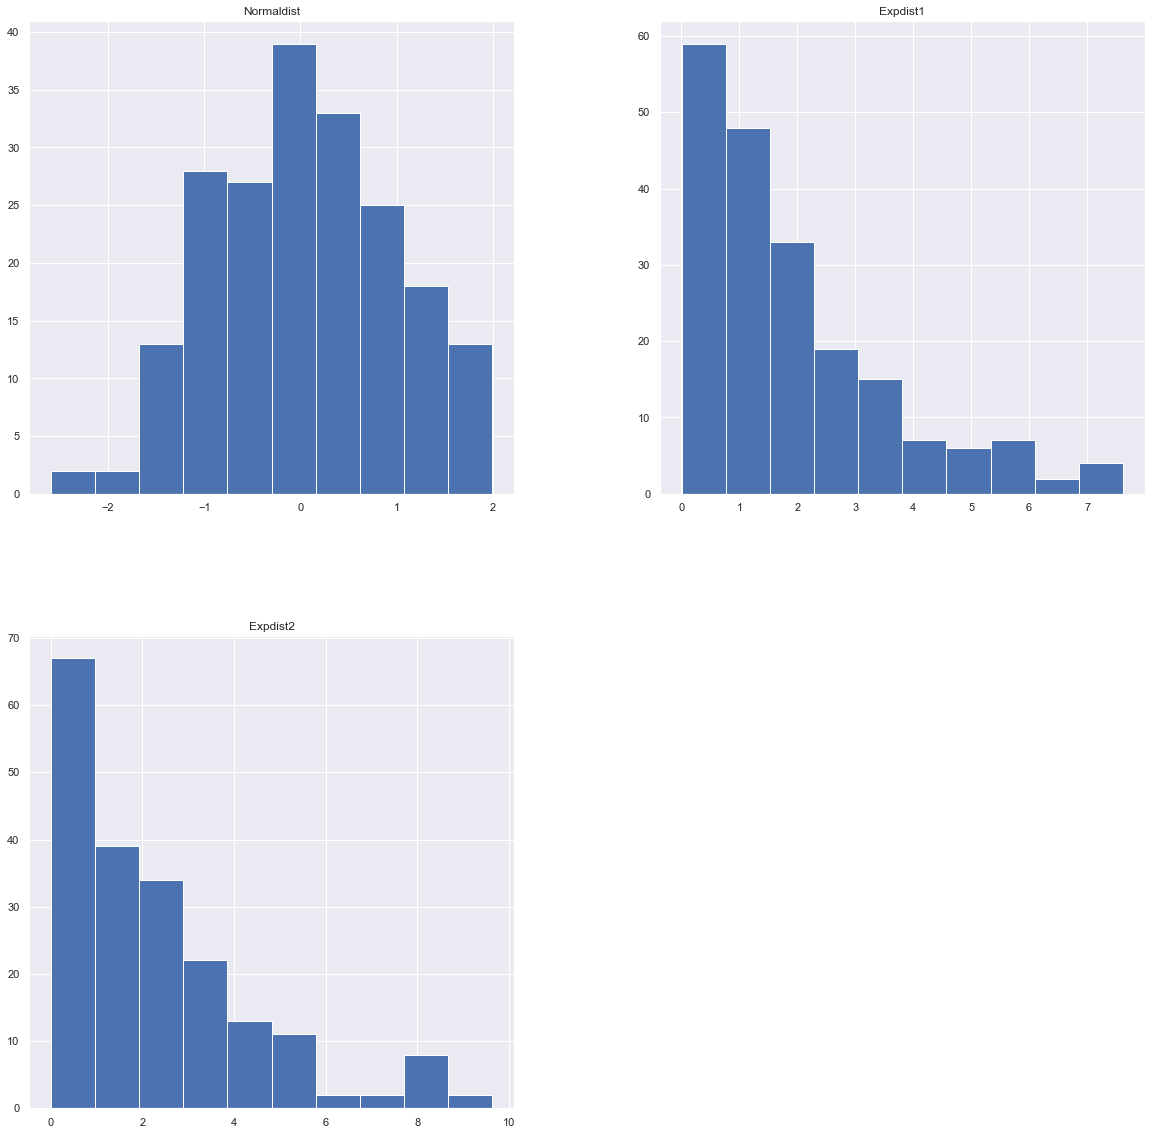

In [17]:
nan_metric_plot = data_clean_copy.hist(figsize = (20,20))

### Write a report about cells with outliers, thier z-scores and substituted values.

With regards to the Outliers and detecting them, this was made possible via extracting outliers and their index to an array to which i then used to drop the element at the associated index based on the zscore tests. After this the entirety of the dataset was tested against the saved outliers and then changed to Na once it was discovered to be an outlier, this then went on to then calculating the inplace mean for the na value and then filling it in with the fillna function for the given index. using the zscores we can see that we found a total of 0 outliers in the Normaldist column, we found 5 outliers in Expdist1 colunm and we found 3 outliers in Expdist2 coloumn. upon finding these outliers, we then created a new dataset while adding the Na inputed columns to it to then be imputed inplace for a mean calculated inplace via numpy row-wise rather then externally and then iterated and inputed into the dataframe. The substituted values seem to be fitting, however depending on the visual dispersion of data, the mean shouldve been used for NormalDist but the median should've been used to impute the missing data for Expdist1 and Expdist2 missing values within the coloumns as judged by the visual resperesentation of central tendancy of coloumns

**Exercise 5.3: PCA**

1) Apply PCA to the data - output of **Exercise 5.2** (with no outliers) in order to reduce the dimension from 3 to 2 (use "PCA(n_components = 2)". 

2) Transform your data (3 dimensional) to a new data (2 dimensional) by applying "pca.transform", then print the shapes and the first 5 rows of your data and new/transformed data.

In [18]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca.fit(meanimputed_df)
mean_pca = pca.transform(meanimputed_df)
print("original shape: ", meanimputed_df.shape)
print("transformed shape: ", mean_pca.shape)
print('----------------------------------')

print('meanimputed_df')
print(meanimputed_df.head(5))
print('----------------------------------')
print('mean_pca')

print(mean_pca[:5,:])

original shape:  (200, 3)
transformed shape:  (200, 2)
----------------------------------
meanimputed_df
   Normaldist  Expdist1  Expdist2
0    0.223196  1.751141  4.063507
1   -0.139826  3.147963  0.779660
2   -0.408956  3.274980  1.522829
3    0.507758  0.558921  3.276307
4    0.785782  2.080475  0.106692
----------------------------------
mean_pca
[[ 1.65239125 -0.41867495]
 [-1.36706788  1.48624997]
 [-0.61166752  1.49864408]
 [ 0.68492992 -1.47598527]
 [-2.20559977  0.52302557]]


In [19]:
print(pca.components_)

[[-0.00560459  0.15818442  0.98739368]
 [-0.01712501  0.9872492  -0.15825848]]


In [20]:
print(pca.explained_variance_)

[4.5681563  2.84579879]
